<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Entangle002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🧠 Act II: The Curvature Lattice — δ = 0.75, κ = 0.6, δ/κ = 1.250
Final Mean Entropy: -162.2625
Final Curvature: 5395.8333


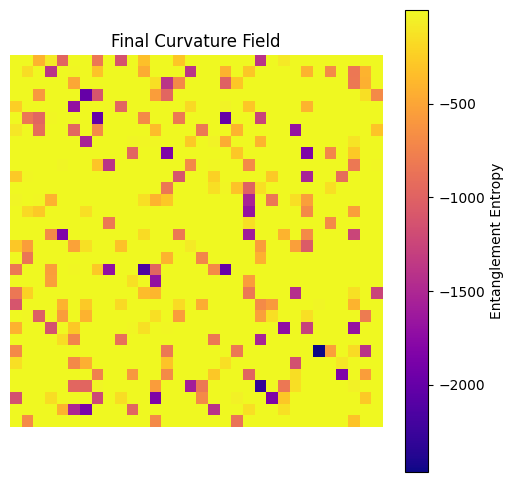

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Step 1: Initialize 2D Entanglement Grid
# -------------------------------
def initialize_grid_2d(size=32, seed=42):
    np.random.seed(seed)
    return np.random.normal(loc=1.0, scale=0.01, size=(size, size))

# -------------------------------
# Step 2: Entanglement Evolution Rule (2D)
# -------------------------------
def evolve_entropy_2d(grid, delta, kappa, steps=100):
    history = [grid.copy()]
    curvature_trace = []

    for t in range(steps):
        safe_max = max(np.max(grid), 1e-6)
        injection = delta * np.sin(np.pi * grid / safe_max)
        safe_grid = np.clip(grid, -10, 10)
        damping = kappa * np.exp(-safe_grid)
        update = injection - damping
        grid += update / (1 + t)
        curvature = np.std(update)
        curvature_trace.append(curvature)
        history.append(grid.copy())

    return np.array(history), np.array(curvature_trace)

# -------------------------------
# Step 3: Visualize Final Curvature Field
# -------------------------------
def plot_final_curvature(grid, title="Final Curvature Field"):
    plt.figure(figsize=(6, 6))
    plt.imshow(grid, cmap='plasma', interpolation='nearest')
    plt.colorbar(label='Entanglement Entropy')
    plt.title(title)
    plt.axis('off')
    plt.show()

# -------------------------------
# Step 4: Run Simulation
# -------------------------------
delta = 0.75
kappa = 0.60
grid = initialize_grid_2d()
history, curvature_trace = evolve_entropy_2d(grid, delta, kappa)
final_grid = history[-1]

print(f"🧠 Act II: The Curvature Lattice — δ = {delta}, κ = {kappa}, δ/κ = {delta/kappa:.3f}")
print(f"Final Mean Entropy: {np.mean(final_grid):.4f}")
print(f"Final Curvature: {curvature_trace[-1]:.4f}")

plot_final_curvature(final_grid)
